<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/assignments/03_Assignment_Model_Selection_inprogress_ALL_done.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPM 204: Assignment 3

### Due 23th April 2026 9AM

#### For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
#### Please make sure that you are not simply copying each other's code, but rather striving to understand each other's work and learn from it.
#### Additionally, please provide the R code at the end of your solution and include R commands along with R outputs. This will help to describe your solutions more clearly.

In [1]:
## load required packages

In [49]:
install.packages('reshape2')
install.packages('tidyverse')
install.packages('sjPlot')
library(sjPlot)
library(tidyverse)
library(reshape2)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘reformulas’, ‘effectsize’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘parameters’, ‘performance’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’



Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




* The data set was developed by Leathwick et al. in 2008 for research and conservation planning in New Zealand. It describes species data, which were recorded at 13,369 sites across New Zealand's rivers, spanning the major environmental gradients.
* *Anguilla australis* was caught at 20% of these sites. This data set is much larger than what is typically available in ecology. Therefore, we subsample the sites, partitioning off some records for modeling and keeping the rest for independent evaluation.  

* The explanatory variables used in this study were a set of 11 functionally relevant environmental predictors (Table 1).
* These variables summarize conditions over several spatial scales, including the local (segment and reach) scale, upstream catchment scale, and downstream to the sea.
* Most of these variables were available as GIS data for the full river system in New Zealand, enabling us to make predictions for all rivers.
* However, one variable, `LocSed`, which described local substrate conditions, only had records at 82% of the sites. The 12th variable was categorical, describing the fishing method (Table 1).

## Aim of the analysis
### Given these records and covariates, we want to model the joint probability of occurrence and capture of *A. australis*.

## Section 0: Model data

#### Q1: Read the data file "A_australis_model_data.csv" in R and answer the following subquestions
Q1a: Number of rows and columns  
Q1b: Number of possible covariates in the data  
Q1c: Identify number of quantitative and categorical variables in the data   
Q1d: For each possible covariate, how many missing values are present?

#### Points: 5

ANSWERS:

1a) 1000 rows, 14 columns

1b) 12 covariates

1c) 11 quantitative values and 1 categorical variable

1d) Like mentioned in the beginning of the assignment, LocSed only had records for 82% of the sites. After running colSums(is.na(data)), it was found that 176 values are missing for LocSed. However, all the other varibales had 0 missing values.

In [4]:
data <- read.csv('/content/A_australis_model_data.csv')
head(data)

,Site,Angaus,SegSumT,SegTSeas,SegLowFlow,DSDist,DSMaxSlope,USAvgT,USRainDays,USSlope,USNative,DSDam,Method,LocSed
,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
1,1,0,16.0,-0.10,1.036,50.20,0.57,0.09,2.470,9.8,0.81,0,electric,4.8
2,2,1,18.7,1.51,1.003,132.53,1.15,0.20,1.153,8.3,0.34,0,electric,2.0
3,3,0,18.3,0.37,1.001,107.44,0.57,0.49,0.847,0.4,0.00,0,spo,1.0
4,4,0,16.7,-3.80,1.000,166.82,1.72,0.90,0.210,0.4,0.22,1,electric,4.0
5,5,1,17.2,0.33,1.005,3.95,1.15,-1.20,1.980,21.9,0.96,0,electric,4.7
6,6,0,15.1,1.83,1.015,11.17,1.72,-0.20,3.300,25.7,1.00,0,electric,4.5


In [5]:
#number of rows and columns
dim(data)

[1] 1000   14

In [6]:
#look at structure ir snapshot of entire dataset
str(data)

'data.frame':	1000 obs. of  14 variables:
 $ Site      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Angaus    : int  0 1 0 0 1 0 0 0 0 1 ...
 $ SegSumT   : num  16 18.7 18.3 16.7 17.2 15.1 12.7 18.1 18.9 18.2 ...
 $ SegTSeas  : num  -0.1 1.51 0.37 -3.8 0.33 1.83 2.17 1 1.59 0.79 ...
 $ SegLowFlow: num  1.04 1 1 1 1 ...
 $ DSDist    : num  50.2 132.53 107.44 166.82 3.95 ...
 $ DSMaxSlope: num  0.57 1.15 0.57 1.72 1.15 1.72 2.86 2.29 0.4 3.43 ...
 $ USAvgT    : num  0.09 0.2 0.49 0.9 -1.2 -0.2 1.45 0.47 0.25 0.02 ...
 $ USRainDays: num  2.47 1.153 0.847 0.21 1.98 ...
 $ USSlope   : num  9.8 8.3 0.4 0.4 21.9 25.7 9.6 4.9 9.8 20.5 ...
 $ USNative  : num  0.81 0.34 0 0.22 0.96 1 0.09 0.02 0.74 0.92 ...
 $ DSDam     : int  0 0 0 1 0 0 0 0 0 0 ...
 $ Method    : chr  "electric" "electric" "spo" "electric" ...
 $ LocSed    : num  4.8 2 1 4 4.7 4.5 4.3 NA NA 3.6 ...


In [7]:
#count missing values in columns
colSums(is.na(data))

Site     Angaus    SegSumT   SegTSeas SegLowFlow     DSDist DSMaxSlope 
         0          0          0          0          0          0          0 
    USAvgT USRainDays    USSlope   USNative      DSDam     Method     LocSed 
         0          0          0          0          0          0        176

### Understanding the dataset

The following is a list of variables and their descriptions.

| Covariate | Description | Mean and range |
|-----------|-------------|----------------|
| **Reach scale covariate** |  |  |
| LocSed | Weighted average of proportional cover of bed sediment | 3.77 (1–7) |
| **Segment scale covariates** |  |  |
| SegSumT | Summer air temperature (°C) | 16.3 (8.9–19.8) |
| SegTSeas | Winter air temperature (°C), normalized with respect to SegJanT | 0.36 (–4.2–4.1) |
| SegLowFlow | Segment low flow (m³ s⁻¹), fourth root transformed | 1.092 (1.0–4.09) |
| **Downstream covariates** |  |  |
| DSDist | Distance to coast (km) | 74 (0.03–433.4) |
| DSDam | Presence of known downstream obstructions, mostly dams | 0.18 (0 or 1) |
| DSMaxSlope | Maximum downstream slope (°) | 3.1 (0–29.7) |
| **Upstream/catchment scale covariates** |  |  |
| USAvgT | Average temperature in catchment (°C) compared with segment, normalized with respect to SegJanT | –0.38 (–7.7–2.2) |
| USRainDays | Days per month with rain >25 mm | 1.22 (0.21–3.30) |
| USSlope | Average slope in the upstream catchment (°) | 14.3 (0–41.0) |
| USNative | Area with indigenous forest (proportion) | 0.57 (0–1) |
| **Fishing method** |  |  |
| Method | Fishing method in five classes: electric, net, spot, trap, mixture | NA |

`LocSed`: 1 = mud, 2 = sand, 3 = fine gravel; 4 = coarse gravel; 5 = cobble; 6 = boulder; 7 = bedrock    
Even though the interpretation for `LocSed` can be categorical, this is a weighted average of proportion of cover of bed sediment. Researchers have converted their readings into numeric data; therefore, it is not necessary to convert this variable into a factor.

## Section 1: Data exploration

Q2. Find the quantitative variables that are highly correlated with each other.  
hint: use correlation plots shown previously in class.  
Points: 2  

In [8]:
#look at the first 6 rows (like what we saw when loading the data)
head(data[])

,Site,Angaus,SegSumT,SegTSeas,SegLowFlow,DSDist,DSMaxSlope,USAvgT,USRainDays,USSlope,USNative,DSDam,Method,LocSed
,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>,<dbl>
1,1,0,16.0,-0.10,1.036,50.20,0.57,0.09,2.470,9.8,0.81,0,electric,4.8
2,2,1,18.7,1.51,1.003,132.53,1.15,0.20,1.153,8.3,0.34,0,electric,2.0
3,3,0,18.3,0.37,1.001,107.44,0.57,0.49,0.847,0.4,0.00,0,spo,1.0
4,4,0,16.7,-3.80,1.000,166.82,1.72,0.90,0.210,0.4,0.22,1,electric,4.0
5,5,1,17.2,0.33,1.005,3.95,1.15,-1.20,1.980,21.9,0.96,0,electric,4.7
6,6,0,15.1,1.83,1.015,11.17,1.72,-0.20,3.300,25.7,1.00,0,electric,4.5


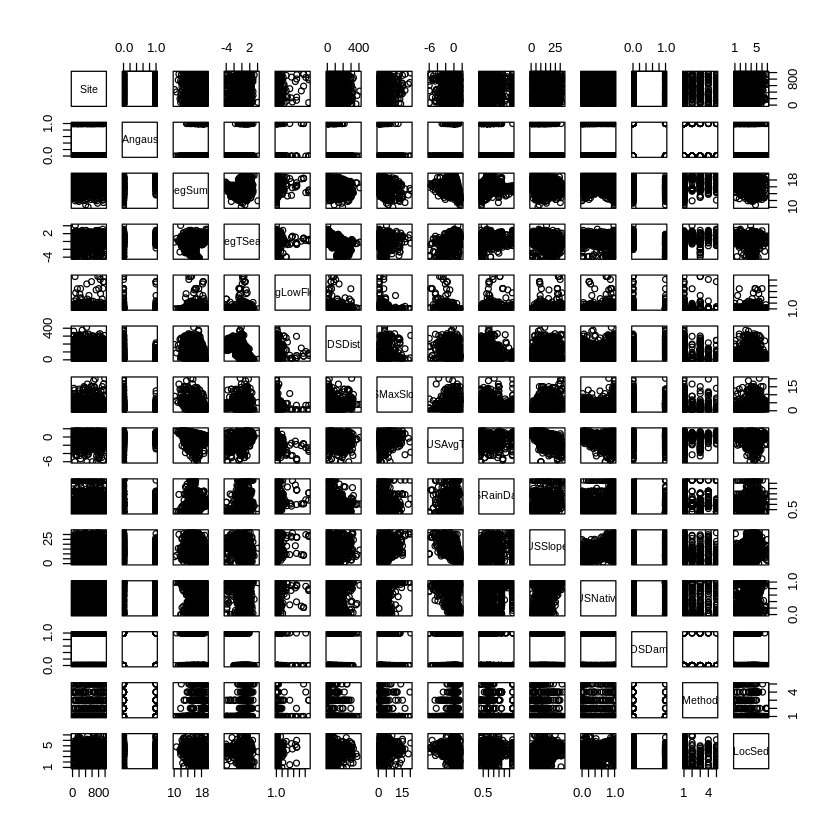

In [9]:
#scatterpliots to show every variable plotted against every other variable
plot(data[])

* The plot function can be difficult to read with large data points.
* Let's use another plotting function from `ggplot` to explore the correlation between our covariates.

In [10]:
#define numeric covariates list
covariates_numeric = names(data)[!(names(data) %in% c('Site', 'Angaus', "Method"))]
covariates_numeric

[1] "SegSumT"    "SegTSeas"   "SegLowFlow" "DSDist"     "DSMaxSlope"
 [6] "USAvgT"     "USRainDays" "USSlope"    "USNative"   "DSDam"     
[11] "LocSed"

In [11]:
#calcualting correlation coeficient
cormat <- round(cor(data[,covariates_numeric]),2)
cormat

,SegSumT,SegTSeas,SegLowFlow,DSDist,DSMaxSlope,USAvgT,USRainDays,USSlope,USNative,DSDam,LocSed
SegSumT,1.00,0.26,-0.01,-0.36,-0.40,-0.02,0.04,-0.22,-0.34,-0.23,NA
SegTSeas,0.26,1.00,-0.05,-0.64,-0.19,0.41,0.35,-0.24,-0.17,-0.55,NA
SegLowFlow,-0.01,-0.05,1.00,0.05,-0.09,-0.42,0.11,0.16,0.06,0.02,NA
DSDist,-0.36,-0.64,0.05,1.00,0.30,-0.24,-0.27,0.13,0.16,0.58,NA
DSMaxSlope,-0.40,-0.19,-0.09,0.30,1.00,-0.07,-0.04,0.34,0.36,0.28,NA
USAvgT,-0.02,0.41,-0.42,-0.24,-0.07,1.00,0.01,-0.58,-0.36,-0.23,NA
USRainDays,0.04,0.35,0.11,-0.27,-0.04,0.01,1.00,0.10,0.22,-0.21,NA
USSlope,-0.22,-0.24,0.16,0.13,0.34,-0.58,0.10,1.00,0.64,0.08,NA
USNative,-0.34,-0.17,0.06,0.16,0.36,-0.36,0.22,0.64,1.00,0.13,NA
DSDam,-0.23,-0.55,0.02,0.58,0.28,-0.23,-0.21,0.08,0.13,1.00,NA


#### since there are missing values in *LocSed* lets redo the correlation matrix by dropping rows with missing data

In [12]:
cormat <- round(cor(drop_na(data[,covariates_numeric])),2)
cormat

,SegSumT,SegTSeas,SegLowFlow,DSDist,DSMaxSlope,USAvgT,USRainDays,USSlope,USNative,DSDam,LocSed
SegSumT,1.00,0.25,-0.01,-0.34,-0.41,-0.04,0.07,-0.18,-0.33,-0.23,-0.32
SegTSeas,0.25,1.00,-0.06,-0.65,-0.18,0.40,0.34,-0.22,-0.18,-0.55,-0.09
SegLowFlow,-0.01,-0.06,1.00,0.05,-0.10,-0.46,0.13,0.16,0.10,0.00,0.09
DSDist,-0.34,-0.65,0.05,1.00,0.29,-0.21,-0.28,0.10,0.14,0.58,0.08
DSMaxSlope,-0.41,-0.18,-0.10,0.29,1.00,-0.06,-0.06,0.31,0.34,0.28,0.24
USAvgT,-0.04,0.40,-0.46,-0.21,-0.06,1.00,0.03,-0.58,-0.34,-0.17,-0.26
USRainDays,0.07,0.34,0.13,-0.28,-0.06,0.03,1.00,0.09,0.23,-0.23,0.13
USSlope,-0.18,-0.22,0.16,0.10,0.31,-0.58,0.09,1.00,0.63,0.01,0.37
USNative,-0.33,-0.18,0.10,0.14,0.34,-0.34,0.23,0.63,1.00,0.10,0.39
DSDam,-0.23,-0.55,0.00,0.58,0.28,-0.17,-0.23,0.01,0.10,1.00,-0.04


#### Q3: Which two covariates have the highest correlation coefficient? Are there any other pairs that concern you?
Q3a: Which correlation coefficient is being calculated by the command cor? What is the default method for calculating the correlation coefficient? What other methods are possible?  
Points: 5  

ANSWER:

Pearson correlation coefficient is the default if it isn't specified. But Spearman and Kendall are other possible methods.

In [13]:
?cor

#### Plotting correlation matrix for easier visualization

#### Q4: Use following code to plot the correlation matrix you generated above  
Points: 2

In [14]:
library(reshape2)
melted_cormat <- melt(cormat)
head(melted_cormat)


,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,SegSumT,SegSumT,1.00
2,SegTSeas,SegSumT,0.25
3,SegLowFlow,SegSumT,-0.01
4,DSDist,SegSumT,-0.34
5,DSMaxSlope,SegSumT,-0.41
6,USAvgT,SegSumT,-0.04


In [15]:
#### complete the command below to get the desired plot
ggplot(data = , aes(x=Var1, y=Var2, fill=value)) +
  geom_tile()

ERROR: [1m[33mError[39m in `fortify()`:[22m
[1m[22m[33m![39m `data` must be a [34m<data.frame>[39m, or an object coercible by `fortify()`,
  or a valid [34m<data.frame>[39m-like object coercible by `as.data.frame()`, not a
  <ggplot2::mapping> object.
[36mℹ[39m Did you accidentally pass `aes()` to the `data` argument?


#### Q5: Let's make the plot much more readable. Use the following code to create plots for your correlation matrix.
Change the title of the legend bar for the plot based on the correlation coefficient you are calculating.  
Points: 3

In [16]:
### function to reorder the correlation matrix
reorder_cormat <- function(cormat){
# Use correlation between variables as distance
dd <- as.dist((1-cormat)/2)
hc <- hclust(dd)
cormat <-cormat[hc$order, hc$order]
}

#### Which dataframe object will you use here in the command below?

In [26]:
cormat <- reorder_cormat(cormat)

In [21]:
# Get upper triangle of the correlation matrix
get_upper_tri <- function(cormat){
cormat[lower.tri(cormat)]<- NA
return(cormat)
}

## remove the upper half of the matrix
upper_tri <- get_upper_tri(cormat)

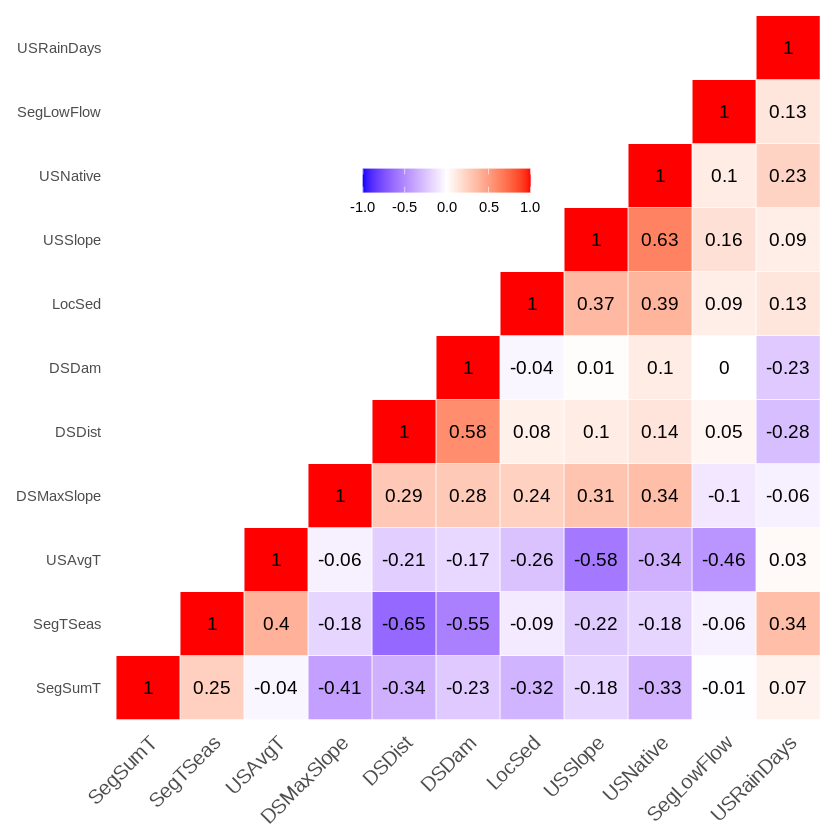

In [22]:
melted_cormat <- melt(upper_tri, na.rm = TRUE)
# Create a ggheatmap
ggheatmap <- ggplot(melted_cormat, aes(Var2, Var1, fill = value))+
 geom_tile(color = "white")+
 scale_fill_gradient2(low = "blue", high = "red", mid = "white",
   midpoint = 0, limit = c(-1,1), space = "Lab",
    name="") +
  theme_minimal()+ # minimal theme
 theme(axis.text.x = element_text(angle = 45, vjust = 1,
    size = 12, hjust = 1))+
 coord_fixed()
# Print the heatmap
ggheatmap +
geom_text(aes(Var2, Var1, label = value), color = "black", size = 4) +
theme(
  axis.title.x = element_blank(),
  axis.title.y = element_blank(),
  panel.grid.major = element_blank(),
  panel.border = element_blank(),
  panel.background = element_blank(),
  axis.ticks = element_blank(),
  legend.justification = c(1, 0),
  legend.position = c(0.6, 0.7),
  legend.direction = "horizontal")+
  guides(fill = guide_colorbar(barwidth = 7, barheight = 1,
                title.position = "top", title.hjust = 0.5))

#### I will keep a close eye on covariates that have correlation coefficient higher than 0.2%. (more than 20% correlation)

## Section 2: Univariate model building and exploration

##### Q6: Use the following code to run univariate models.
Q6a: List the significant covariates.   
Q6b: Scale the covariates and rerun the analysis.  
Q6c: What differences do you see between the scaled and unscaled (raw) analyses? Did any new covariates become significant?  

Points: 6

ANSWERS:

6a) significant covariates: SegSumT, SegTSeas, USAvgT, USSlope, USRainDays, DSMasSlope, LocSed, DSDam, USNative.


6c) DSDist in the unscaled version was unlclear if it was significant or not, but now it is no longer on the line and is shown as significant. Rescaling made it possible to compare the estimates.

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: ggthemes



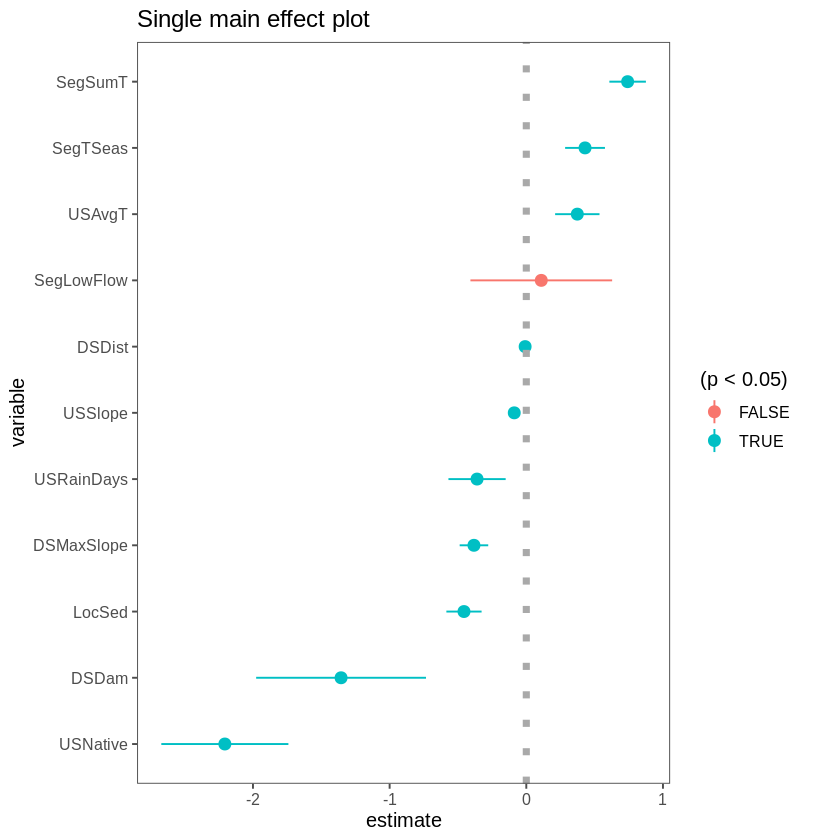

In [29]:
#### complete the command below to get the desired plot and output

library(plyr)
covariates <- names(data)[!( names(data) %in% c('Site', 'Angaus', "Method"))]
getBetaAndSe <- function(covar){
    coefs <- glm(as.formula(paste("Angaus ~ ", covar)), data = data, family = "binomial") %>%
        summary %>% coef
    data.frame(variable = covar,
               estimate = coefs[2,1],
               se = coefs[2,2],
               p = coefs[2,4])
}

install.packages('ggthemes')
require(ggthemes)
beta.table <- adply(t(covariates), 2, getBetaAndSe) %>%
            arrange(estimate) %>%
            mutate(low = estimate - 2*se,
                         high = estimate + 2*se,
                         variable = reorder(variable, order(estimate)))

# note - the "reorder" was necessary to make the variables plot
# in the right order in ggplot ... but it took TOO LONG to figure out!

ggplot(beta.table, aes(y=estimate, x=variable, ymin=low, ymax=high, color = (p < 0.05))) +
            geom_pointrange() +
            geom_hline(yintercept = 0, col="darkgrey", lty = 3, lwd=2) +
            coord_flip() + theme_few() + ggtitle("Single main effect plot")

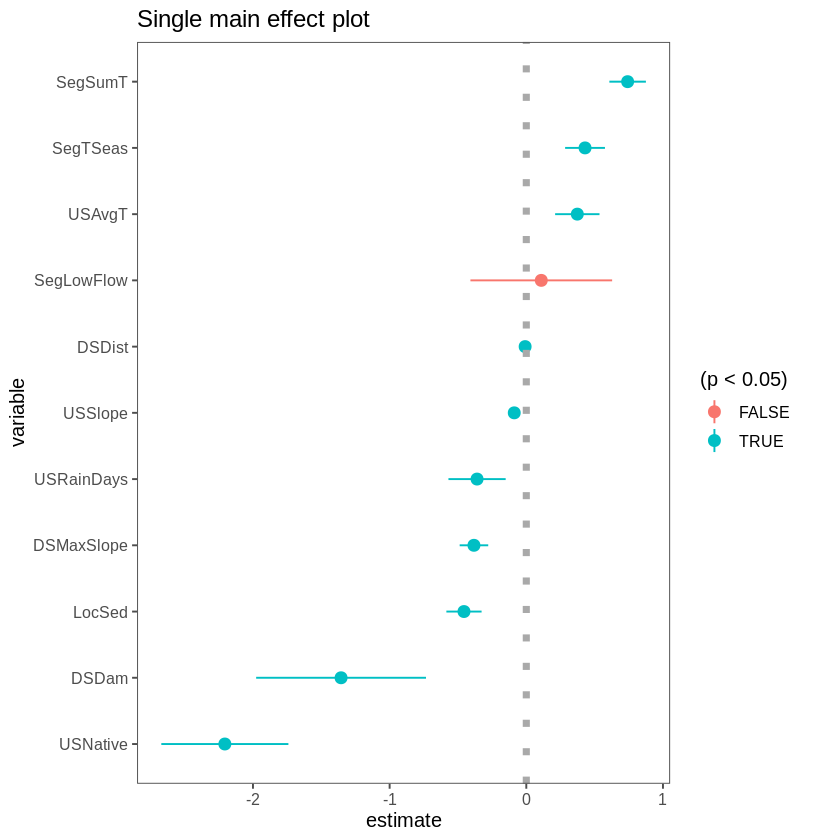

In [31]:
#### complete the command below to get the desired plot and output
covariates <- names(data)[!( names(data) %in% c('Site', 'Angaus', "Method"))]
getBetaAndSe <- function(covar){
    coefs <- glm(as.formula(paste("Angaus ~ ", covar)), data = data, family = "binomial") %>%
        summary %>% coef
    data.frame(variable = covar,
               estimate = coefs[2,1],
               se = coefs[2,2],
               p = coefs[2,4])
}

require(ggthemes)
beta.table <- adply(t(covariates), 2, getBetaAndSe) %>%
            arrange(estimate) %>%
            mutate(low = estimate - 2*se,
                         high = estimate + 2*se,
                         variable = reorder(variable, order(estimate)))

# note - the "reorder" was necessary to make the variables plot
# in the right order in ggplot ... but it took TOO LONG to figure out!

ggplot(beta.table, aes(y=estimate, x=variable, ymin=low, ymax=high, color = (p < 0.05))) +
            geom_pointrange() +
            geom_hline(yintercept = 0, col="darkgrey", lty = 3, lwd=2) +
            coord_flip() + theme_few() + ggtitle("Single main effect plot")

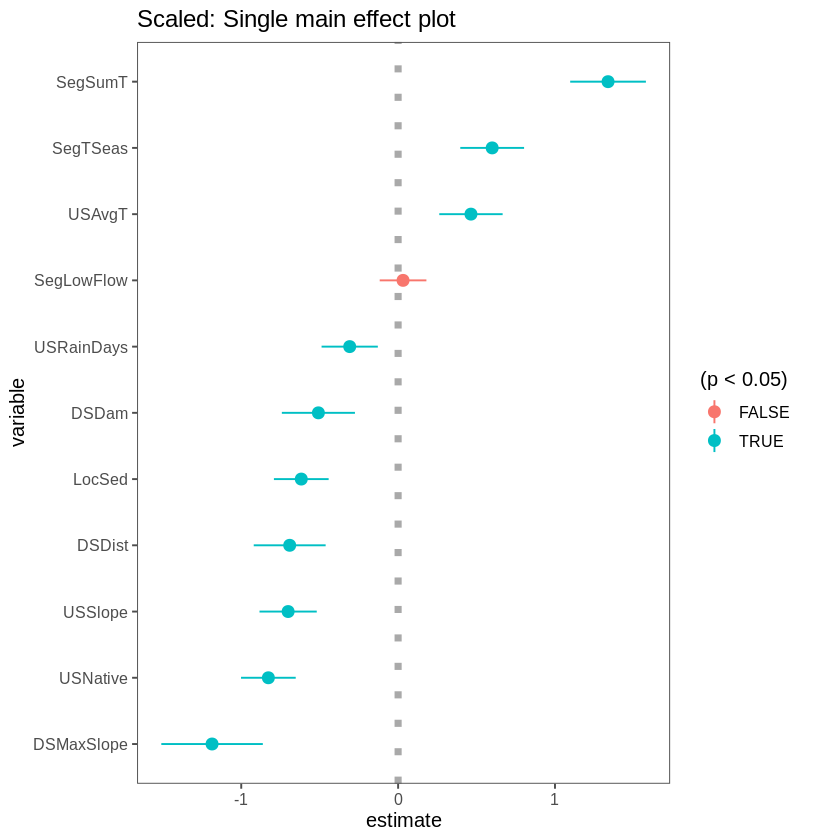

In [33]:
covariates <- names(data)[!( names(data) %in% c('Site', 'Angaus', "Method"))]
# Create a scaled version of the data for relevant covariates
data_scaled <- data
data_scaled[, covariates] <- scale(data[, covariates])

getBetaAndSe <- function(covar){
  coefs <- glm(as.formula(paste('Angaus ~', covar)),
               data = data_scaled,
               family = 'binomial') %>%
    summary %>% coef
  data.frame(variable = covar,
             estimate = coefs[2,1],
             se       = coefs[2,2],
             p        = coefs[2,4])
}

beta.table <- adply(t(covariates), 2, getBetaAndSe) %>%
  arrange(estimate) %>%
  mutate(low  = estimate - 2*se,
         high = estimate + 2*se,
         variable = reorder(variable, order(estimate)))

ggplot(beta.table, aes(y=estimate, x=variable, ymin=low, ymax=high,
                       color = (p < 0.05))) +
  geom_pointrange() +
  geom_hline(yintercept = 0, col='darkgrey', lty = 3, lwd=2) +
  coord_flip() + theme_few() + ggtitle('Scaled: Single main effect plot')

#### Q7: Run a single univariate model for categorical covariate

Points: 2

In [38]:
#univariate model with method as the only covariate
cat_model <- glm(Angaus ~ Method, data = data, family = 'binomial')
summary(cat_model)


Call:
glm(formula = Angaus ~ Method, family = "binomial", data = data)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -1.35885    0.08948 -15.187  < 2e-16 ***
Methodmixture  0.98156    0.27972   3.509  0.00045 ***
Methodnet     -0.19929    0.32997  -0.604  0.54587    
Methodspo     -0.99252    0.53071  -1.870  0.06146 .  
Methodtrap    -1.00200    0.47617  -2.104  0.03535 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1006.33  on 999  degrees of freedom
Residual deviance:  982.69  on 995  degrees of freedom
AIC: 992.69

Number of Fisher Scoring iterations: 4


## Section 3: Model selection
#### Q8: Model selection procedure

This is the main section of the assignment.
Please closely follow the instructions below.  
###### Start by creating a global model.
* Start with a global model. Covariates for global model will be decided on
1. Correlation coefficient: Select one independent variable from the covariates that have an $r^2>0.7$. In this dataset, there are a couple of covariate pairs that have an $r^2$ close to 0.7. Select the most relevant covariate.
2. Do not include covariates that are insignificant in the univariate analysis.
3. Explore the global model and inform which covariates are significant. Run the model by removing rows with missing values.
4. Use the `anova` function to check if the inclusion of covariates significantly improves the model fit (by increasing the likelihood).
5. Describe the results of the `anova` test (analysis of deviance).
6. Use the `stepAIC` function (in `MASS`) to march through the inclusion and removal of different covariates to find the one with the lowest AIC.
7. The outputs of `stepAIC` will not result in multiple steps for this dataset. The model is already close to MAM.
8. Remove covariates from the model resulted from the `stepAIC` function and re-fit the model with reduced covariates. Check AIC for it. What do you observe in terms of $B$ estimates, $odds$ $ratios$, and $significance$?

#### Points 25


ANSWER:

8. SegSumT reduces the devaince the most compared to the other variables. It explains the most "work" in eel presence. The bigger the deviance reduction, the more that variable is helping the model explain the data. Variabels with the lowest deviance are USSlope, DSDam, and LocSed, therefore they do not improve the model and can be removed.

- After removing non-significant covariates from the model, DSDist went from significant to non-significant, but the model kept the variable anyways because the AIC remained low, even with it.
- Comparing the two models, Global model (glm1) give AIC: 604.37. Reduced model (glm2) gives AIC: 603.13. The coefficients for shared varaiables stayed very similar between the two models, which is normal and expected when removing non-significant variables. USNative became significant in the reduced model, suggesting its effect was masked by non-significant varibles in the global model.

In [39]:
## add Covariates that you want to exclude from the main model in the list below along with Site and Angaus (output variable)
#excluding SegLowFlow (was the only non-signifcant covariate/red dot)
#also dropping SegTSeas/winter temp and keeping DSDist bc DSDist makes bioloigcal sense
#in affecting eels migration than winter temp
#site dropped bc just an ID
#Angaus dropped bc its the outcome
#SegTSeas dropeed bc highly correlated w/ DSDist; only need one of them
covariates_main_effects <- names(data)[!(names(data) %in%
  c('Site', 'Angaus', 'SegLowFlow', 'SegTSeas'))]
covariates_main_effects


[1] "SegSumT"    "DSDist"     "DSMaxSlope" "USAvgT"     "USRainDays"
 [6] "USSlope"    "USNative"   "DSDam"      "Method"     "LocSed"

#### Main effects model

In [41]:
## remove missing data from our dataframe. Use the this data for your model building.
data_red = drop_na(data)

In [42]:
maineffects.glm <- glm(Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT +
                                USRainDays + USSlope + USNative + DSDam +
                                Method + LocSed,
                       data = data_red,
                       family = 'binomial')
summary(maineffects.glm)


Call:
glm(formula = Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT + 
    USRainDays + USSlope + USNative + DSDam + Method + LocSed, 
    family = "binomial", data = data_red)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -10.485198   1.576655  -6.650 2.93e-11 ***
SegSumT         0.696898   0.085176   8.182 2.79e-16 ***
DSDist         -0.002636   0.001920  -1.373 0.169878    
DSMaxSlope     -0.143605   0.061805  -2.324 0.020151 *  
USAvgT          0.339626   0.163601   2.076 0.037900 *  
USRainDays     -0.653896   0.189051  -3.459 0.000543 ***
USSlope        -0.027964   0.024382  -1.147 0.251408    
USNative       -0.521477   0.392057  -1.330 0.183484    
DSDam          -0.625040   0.426732  -1.465 0.142999    
Methodmixture  -0.508983   0.420814  -1.210 0.226463    
Methodnet      -1.233359   0.466115  -2.646 0.008144 ** 
Methodspo      -1.721656   0.695967  -2.474 0.013370 *  
Methodtrap     -2.841649   0.594753  -4.778 1.77e-06 ***
LocSed   

In [44]:
print(anova(maineffects.glm, test = 'Chisq'))
## complete the code to get desired outputs

Analysis of Deviance Table

Model: binomial, link: logit

Response: Angaus

Terms added sequentially (first to last)


           Df Deviance Resid. Df Resid. Dev  Pr(>Chi)    
NULL                         823     838.88              
SegSumT     1  165.184       822     673.69 < 2.2e-16 ***
DSDist      1    3.307       821     670.39 0.0689879 .  
DSMaxSlope  1   15.627       820     654.76 7.715e-05 ***
USAvgT      1   14.313       819     640.45 0.0001548 ***
USRainDays  1   16.628       818     623.82 4.548e-05 ***
USSlope     1    0.771       817     623.05 0.3799392    
USNative    1    4.839       816     618.21 0.0278153 *  
DSDam       1    0.673       815     617.54 0.4121316    
Method      4   39.050       811     578.49 6.803e-08 ***
LocSed      1    2.119       810     576.37 0.1454372    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [45]:
require(MASS)
print(best.main.glm <- stepAIC(maineffects.glm, trace = 0))
## complete the code to get desired outputs

Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select





Call:  glm(formula = Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT + 
    USRainDays + USNative + Method, family = "binomial", data = data_red)

Coefficients:
  (Intercept)        SegSumT         DSDist     DSMaxSlope         USAvgT  
   -11.526340       0.721551      -0.003251      -0.185252       0.478778  
   USRainDays       USNative  Methodmixture      Methodnet      Methodspo  
    -0.670830      -0.782234      -0.354125      -1.082231      -1.583330  
   Methodtrap  
    -2.550541  

Degrees of Freedom: 823 Total (i.e. Null);  813 Residual
Null Deviance:	    838.9 
Residual Deviance: 581.1 	AIC: 603.1


In [46]:
## Removing non-signifacnt covariates from the model and reruning the model
maineffects.glm2 <- glm(Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT +
                                  USRainDays + USNative + Method,
                         data = data_red,
                         family = 'binomial')
summary(maineffects.glm2)


Call:
glm(formula = Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT + 
    USRainDays + USNative + Method, family = "binomial", data = data_red)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -11.526340   1.482966  -7.772 7.70e-15 ***
SegSumT         0.721551   0.084023   8.588  < 2e-16 ***
DSDist         -0.003251   0.001806  -1.800 0.071847 .  
DSMaxSlope     -0.185252   0.059617  -3.107 0.001888 ** 
USAvgT          0.478778   0.144803   3.306 0.000945 ***
USRainDays     -0.670830   0.186908  -3.589 0.000332 ***
USNative       -0.782234   0.340795  -2.295 0.021715 *  
Methodmixture  -0.354125   0.409257  -0.865 0.386881    
Methodnet      -1.082231   0.449503  -2.408 0.016057 *  
Methodspo      -1.583330   0.678454  -2.334 0.019610 *  
Methodtrap     -2.550541   0.572657  -4.454 8.43e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 838.88  on

In [51]:
install.packages('sjPlot')
install.packages('sjmisc')
library(sjPlot)
library(sjmisc)

tab_model(maineffects.glm, maineffects.glm2, show.reflvl = TRUE)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘sjmisc’


The following object is masked from ‘package:purrr’:

    is_empty


The following object is masked from ‘package:tidyr’:

    replace_na


The following object is masked from ‘package:tibble’:

    add_case




In [53]:
#### compare two models for their measures of effects
tab_model(maineffects.glm, maineffects.glm2, show.reflvl = TRUE)

In [54]:
#tab_model didnt display output, so running this code next
summary(maineffects.glm)
summary(maineffects.glm2)
AIC(maineffects.glm)
AIC(maineffects.glm2)


Call:
glm(formula = Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT + 
    USRainDays + USSlope + USNative + DSDam + Method + LocSed, 
    family = "binomial", data = data_red)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -10.485198   1.576655  -6.650 2.93e-11 ***
SegSumT         0.696898   0.085176   8.182 2.79e-16 ***
DSDist         -0.002636   0.001920  -1.373 0.169878    
DSMaxSlope     -0.143605   0.061805  -2.324 0.020151 *  
USAvgT          0.339626   0.163601   2.076 0.037900 *  
USRainDays     -0.653896   0.189051  -3.459 0.000543 ***
USSlope        -0.027964   0.024382  -1.147 0.251408    
USNative       -0.521477   0.392057  -1.330 0.183484    
DSDam          -0.625040   0.426732  -1.465 0.142999    
Methodmixture  -0.508983   0.420814  -1.210 0.226463    
Methodnet      -1.233359   0.466115  -2.646 0.008144 ** 
Methodspo      -1.721656   0.695967  -2.474 0.013370 *  
Methodtrap     -2.841649   0.594753  -4.778 1.77e-06 ***
LocSed   


Call:
glm(formula = Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT + 
    USRainDays + USNative + Method, family = "binomial", data = data_red)

Coefficients:
                Estimate Std. Error z value Pr(>|z|)    
(Intercept)   -11.526340   1.482966  -7.772 7.70e-15 ***
SegSumT         0.721551   0.084023   8.588  < 2e-16 ***
DSDist         -0.003251   0.001806  -1.800 0.071847 .  
DSMaxSlope     -0.185252   0.059617  -3.107 0.001888 ** 
USAvgT          0.478778   0.144803   3.306 0.000945 ***
USRainDays     -0.670830   0.186908  -3.589 0.000332 ***
USNative       -0.782234   0.340795  -2.295 0.021715 *  
Methodmixture  -0.354125   0.409257  -0.865 0.386881    
Methodnet      -1.082231   0.449503  -2.408 0.016057 *  
Methodspo      -1.583330   0.678454  -2.334 0.019610 *  
Methodtrap     -2.550541   0.572657  -4.454 8.43e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 838.88  on

[1] 604.3663

[1] 603.1281

## Section 4: Interactions
#### Q9: Selection of interactions

1. Create a dataframe including the output column and all covariates to be tested in the interaction model, removing missing data based on the results of the previous model.
2. Run a full interaction model using the code provided below.
3. Use the `stepAIC` function to find the model with the lowest AIC.
4. Conduct an `ANOVA` test on the best-fitting (lowest AIC) model to identify terms that significantly improve the likelihood.
5. List the interactions that significantly improve the likelihood of the model.
6. Create a final model that includes both interaction terms and main effects.
7. Compare this model to the main effects model using AIC values and odds ratios.

#### Points: 25  


ANSWER:

Comparing the model to the main effects model using AIC values, main effects model: 603.13 and final interaction model: 552.08. The final model has a much lower AIC. This indicates that the relationships between environmental variables and eel presence are not independent. So the interaction between certain variables are important for predicting eel presence, particularly SegSumT/temperature on eel presence depends on distance to the coast/DSDist and proportion of native forest/USNative.

In [55]:
### Create a dataframe with output column and all covariates that you want to test in the interactions model (remove missing data)
COVARIATES <- c('SegSumT', 'DSDist', 'DSMaxSlope', 'USAvgT',
                'USRainDays', 'USNative', 'Method')

interaction_data <- data_red[, c('Angaus', COVARIATES)]
head(interaction_data)
## complete the code to get desired outputs

,Angaus,SegSumT,DSDist,DSMaxSlope,USAvgT,USRainDays,USNative,Method
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,0,16.0,50.20,0.57,0.09,2.470,0.81,electric
2,1,18.7,132.53,1.15,0.20,1.153,0.34,electric
3,0,18.3,107.44,0.57,0.49,0.847,0.00,spo
4,0,16.7,166.82,1.72,0.90,0.210,0.22,electric
5,1,17.2,3.95,1.15,-1.20,1.980,0.96,electric
6,0,15.1,11.17,1.72,-0.20,3.300,1.00,electric


In [59]:
interaction.glm <- glm(Angaus ~ (.)^2,
                       data = interaction_data,
                       family = 'binomial')

best.interaction.glm <- stepAIC(interaction.glm, trace = 0)

summary(best.interaction.glm)## complete the code to get desired outputs

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


Call:
glm(formula = Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT + 
    USRainDays + USNative + Method + SegSumT:DSDist + SegSumT:USAvgT + 
    SegSumT:USRainDays + SegSumT:USNative + SegSumT:Method + 
    DSDist:DSMaxSlope + DSDist:USAvgT + DSDist:Method + USAvgT:Method + 
    USRainDays:Method + USNative:Method, family = "binomial", 
    data = interaction_data)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -4.912e-01  4.121e+00  -0.119  0.90511    
SegSumT                   1.446e-01  2.437e-01   0.593  0.55302    
DSDist                   -3.011e-01  6.329e-02  -4.757 1.96e-06 ***
DSMaxSlope               -2.980e-01  9.181e-02  -3.246  0.00117 ** 
USAvgT                   -5.399e+00  2.491e+00  -2.167  0.03024 *  
USRainDays                3.721e+00  3.017e+00   1.233  0.21744    
USNative                 -1.653e+01  6.260e+00  -2.640  0.00828 ** 
Methodmixture             1.871e+01  1.351e+01   1.385  0.16618    
Me

In [61]:
## complete the code to get desired outputs
print(anova(best.interaction.glm, test = 'Chisq'))

Analysis of Deviance Table

Model: binomial, link: logit

Response: Angaus

Terms added sequentially (first to last)


                   Df Deviance Resid. Df Resid. Dev  Pr(>Chi)    
NULL                                 823     838.88              
SegSumT             1  165.184       822     673.69 < 2.2e-16 ***
DSDist              1    3.307       821     670.39 0.0689879 .  
DSMaxSlope          1   15.627       820     654.76 7.715e-05 ***
USAvgT              1   14.313       819     640.45 0.0001548 ***
USRainDays          1   16.628       818     623.82 4.548e-05 ***
USNative            1    5.515       817     618.30 0.0188525 *  
Method              4   37.176       813     581.13 1.657e-07 ***
SegSumT:DSDist      1   28.408       812     552.72 9.827e-08 ***
SegSumT:USAvgT      1    1.905       811     550.82 0.1674934    
SegSumT:USRainDays  1    1.295       810     549.52 0.2550437    
SegSumT:USNative    1    6.349       809     543.17 0.0117464 *  
SegSumT:Method      4  

In [ ]:
## Run a final model with significant main effects and signficant interactions

In [62]:
final_model <- glm(Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT +
                            USRainDays + USNative + Method +
                            SegSumT:DSDist + SegSumT:USNative +
                            DSDist:DSMaxSlope + DSDist:Method +
                            USRainDays:Method + USNative:Method,
                   data = interaction_data,
                   family = 'binomial')
summary(final_model)


Call:
glm(formula = Angaus ~ SegSumT + DSDist + DSMaxSlope + USAvgT + 
    USRainDays + USNative + Method + SegSumT:DSDist + SegSumT:USNative + 
    DSDist:DSMaxSlope + DSDist:Method + USRainDays:Method + USNative:Method, 
    family = "binomial", data = interaction_data)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -3.735e-03  3.049e+00  -0.001 0.999023    
SegSumT                   9.744e-02  1.739e-01   0.560 0.575227    
DSDist                   -2.729e-01  5.821e-02  -4.688 2.77e-06 ***
DSMaxSlope               -2.722e-01  7.904e-02  -3.443 0.000574 ***
USAvgT                    3.966e-01  1.580e-01   2.510 0.012062 *  
USRainDays               -9.613e-01  2.425e-01  -3.964 7.37e-05 ***
USNative                 -1.092e+01  5.037e+00  -2.167 0.030221 *  
Methodmixture             2.659e+00  1.754e+00   1.516 0.129470    
Methodnet                -4.770e+00  1.449e+00  -3.292 0.000995 ***
Methodspo                -4.907

In [63]:
## Compare model that has interaction terms with model that does not have interaction terms for its measures of effects and AIC
tab_model(maineffects.glm2, final_model, show.reflvl = TRUE)

In [64]:
AIC(maineffects.glm2, final_model)

,df,AIC
,<dbl>,<dbl>
maineffects.glm2,11,603.1281
final_model,26,552.0790


In [65]:
exp(coef(final_model))

(Intercept)                  SegSumT                   DSDist 
            9.962718e-01             1.102349e+00             7.611955e-01 
              DSMaxSlope                   USAvgT               USRainDays 
            7.617281e-01             1.486791e+00             3.823930e-01 
                USNative            Methodmixture                Methodnet 
            1.814561e-05             1.428610e+01             8.484603e-03 
               Methodspo               Methodtrap           SegSumT:DSDist 
            7.395938e-03             2.981287e-03             1.015080e+00 
        SegSumT:USNative        DSDist:DSMaxSlope     DSDist:Methodmixture 
            1.771355e+00             1.003377e+00             1.001872e+00 
        DSDist:Methodnet         DSDist:Methodspo        DSDist:Methodtrap 
            9.798687e-01             1.025543e+00             1.024132e+00 
USRainDays:Methodmixture     USRainDays:Methodnet     USRainDays:Methodspo 
            5.738407e-02             3.193770e+02             4.195224e-01 
   USRainDays:Methodtrap   USNative:Methodmixture       USNative:Methodnet 
            3.819868e+00             6.558500e-01             2.625520e-04 
      USNative:Methodspo      USNative:Methodtrap 
            1.930315e+02             2.331271e+00

## Secton 5: Summarize and present your methods and results
1. Briefly describe, in bullet points, all the steps you took for model selection, starting from data exploration to finalizing the model. Importantly, tell us which results led you to make a specific decision (dropping or selecting a covariate/model).
2. Present your final model result. Describe in words the model results (odds) for two significant main effects and two interactions (if you have any).

### Points: 20

ANSWERS:

Exploring the data:
- Load 1000 observations: 14 variables, identifyied 12 covariates; 11 quantitative and 1 categorical
- Found LocSed missing 176 missing values, and all others were not missing

Correlation:
- Used Pearson correaltion matrix for all numeric covariates
- Found SegTSeas and DSDist most correlated (-0.65), so I dropped one of them from the model to avoid multicollinearity. I kept DSDist because it was more biologically relevant to eel migration

1)Univariate analysis:
- I ran a univariate logistic regression for each covaraite separately
- I excluded SegLowFlow because it was the only non-significant convariate

Global model:
- I fit a logistic regression with the remaining covariates
- ANOVA showed USSlope, DSDam, and LocSed did not significantly improve model fit

Model selection:
- Used stepAIC which removed USSlope, DSDam, and LocSed
- this model reduced the AIC from 604.37 to 603.13

Interaction model:
- tested the interactions using stepAIC
- ANOVA found significant interactions: SegSumT:DSDist, SegSumT:USNative, DSDist:DSMaxSloope, DSDIST:Method, USRainDays:Method, USNative:Method
- the final interaction model hada much lower AIC from 603.13 to 552.08, which indicates the interactions had improved the model fit.

2)Model results:
- Main effects:
  - SegSumT OR=1.10; this means for every degree increase in the summer, the odds of catching an eel increase by 10%
  - USRainDays OR = 0.38; this means for every unit increase in rainy days per month, the odds of cathcing an eel decreases by 62%.

- Interaction:
  - SegSumT:DSDist OR = 1.015; the effect of t emperature on eel presence increases with greater distance from the coast
  - USRainDays:Methodnet OR = 319.4; this means when using a fishing net in areas with more rainy days, the odds of cathcing an eel are dramatically higher compared to other fishing methods.